Instructions:

Importing the Dataset:
Load the dataset into a pandas DataFrame.
Display the first 5 rows of the dataset.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.plotting.register_matplotlib_converters()
print("Setup Complete")

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
file_data = pd.read_csv(url)
file_data.head()

Setup Complete


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Basic Data Exploration:
Data Summary:
Display basic information about the dataset, including the number of rows and columns, data types of each column, and memory usage.
Generate descriptive statistics for the numerical columns (e.g., mean, median, standard deviation).
Check for Missing Values:
Identify any missing values in the dataset and explain how you would handle them if there were any.
Value Counts:
Display the count of each unique species in the species column.

In [14]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('iris')

df.info()
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

stats = df.describe().T
stats['median'] = df.median(numeric_only=True)  
print(stats[['mean', 'median', 'std', 'min', '50%', 'max']])

missing_counts = df.isnull().sum()
print(missing_counts)

print(df['species'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
Rows: 150, Columns: 5
                  mean  median       std  min   50%  max
sepal_length  5.843333    5.80  0.828066  4.3  5.80  7.9
sepal_width   3.057333    3.00  0.435866  2.0  3.00  4.4
petal_length  3.758000    4.35  1.765298  1.0  4.35  6.9
petal_width   1.199333    1.30  0.762238  0.1  1.30  2.5
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


Filtering and Sorting:
Filter the dataset to show only the rows where the sepal_length is greater than 5.0.
Sort the filtered dataset by petal_length in descending order

In [15]:
filtered_df = df[df['sepal_length'] > 5.0]
sorted_df = filtered_df.sort_values(by='petal_length', ascending=False)
sorted_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
118,7.7,2.6,6.9,2.3,virginica
117,7.7,3.8,6.7,2.2,virginica
122,7.7,2.8,6.7,2.0,virginica
105,7.6,3.0,6.6,2.1,virginica
131,7.9,3.8,6.4,2.0,virginica


Creating New Columns:
Create a new column called sepal_petal_ratio which is the ratio of sepal_length to petal_length.

In [16]:
df['sepal_petal_ratio'] = df['sepal_length'] / df['petal_length']
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_petal_ratio
0,5.1,3.5,1.4,0.2,setosa,3.642857
1,4.9,3.0,1.4,0.2,setosa,3.500000
2,4.7,3.2,1.3,0.2,setosa,3.615385
3,4.6,3.1,1.5,0.2,setosa,3.066667
4,5.0,3.6,1.4,0.2,setosa,3.571429


Data Visualization:
Histogram:
Create a histogram to visualize the distribution of sepal_length values.
Scatter Plot:
Create a scatter plot with sepal_length on the x-axis and petal_length on the y-axis. Use different colors to represent different species.
Box Plot:
Create a box plot for the sepal_width values, grouped by species.

/var/folders/9k/1jcvq1z95fg1yw4g_ht7kcsw0000gn/T/ipykernel_60095/2974267179.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


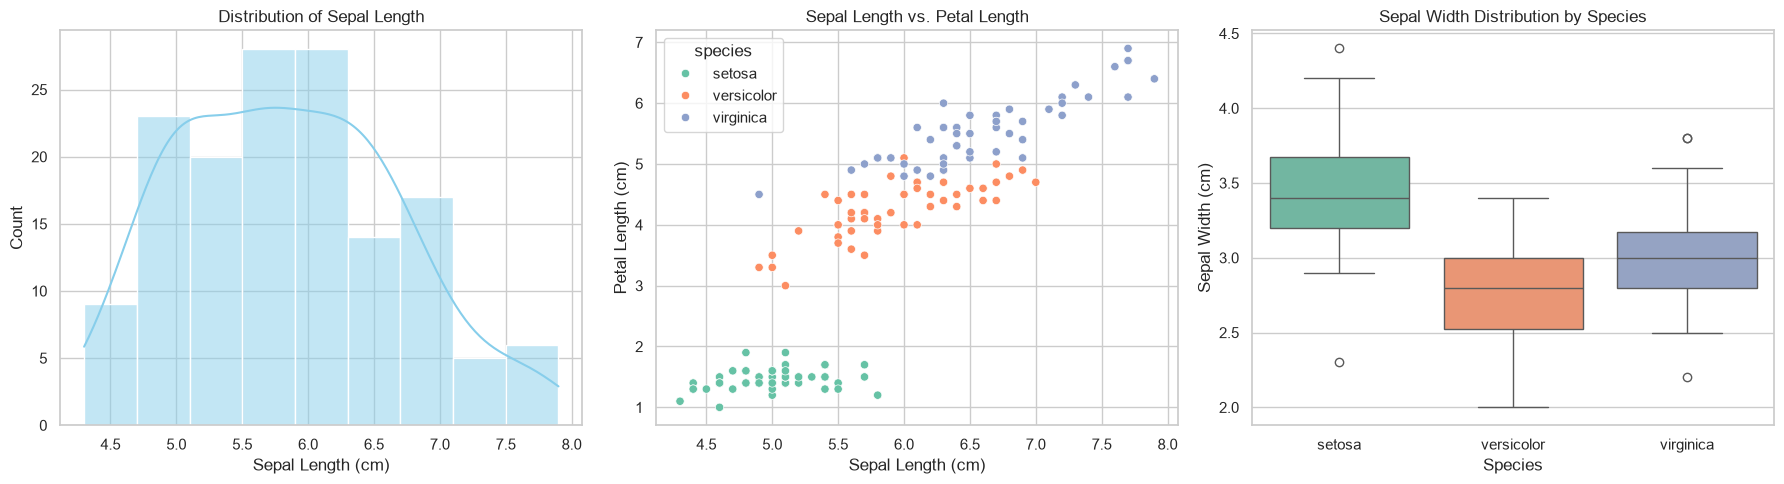

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='sepal_length', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribution of Sepal Length")
axes[0].set_xlabel("Sepal Length (cm)")

sns.scatterplot(
    data=df, 
    x='sepal_length', 
    y='petal_length', 
    hue='species', 
    palette='Set2', 
    ax=axes[1]
)
axes[1].set_title("Sepal Length vs. Petal Length")
axes[1].set_xlabel("Sepal Length (cm)")
axes[1].set_ylabel("Petal Length (cm)")

sns.boxplot(
    data=df, 
    x='species', 
    y='sepal_width', 
    palette='Set2', 
    ax=axes[2]
)
axes[2].set_title("Sepal Width Distribution by Species")
axes[2].set_xlabel("Species")
axes[2].set_ylabel("Sepal Width (cm)")

plt.tight_layout()
plt.show()

Calculate the correlation matrix for the numerical features and create a heatmap to visualize the correlations using seaborn.


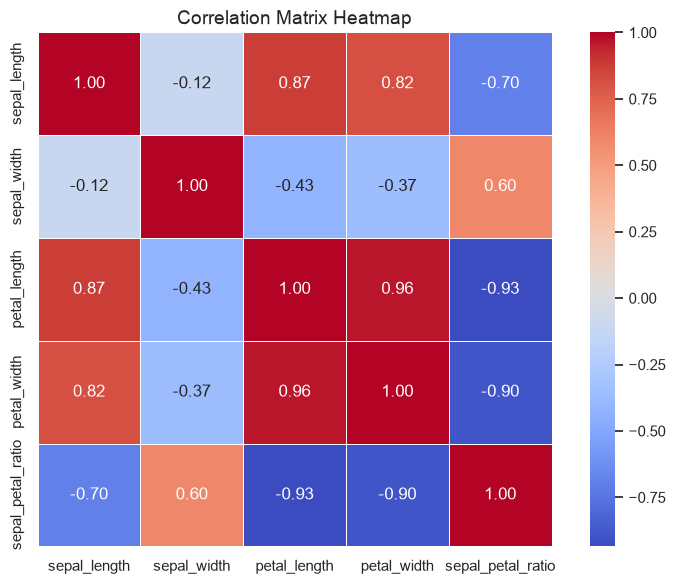

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    square=True
)

plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.tight_layout()
plt.show()